<a href="https://colab.research.google.com/github/iamarjunsrivastava-collab/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 4000
Number of Columns: 28

Dataset Shape: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4

In [5]:
data_types = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

data_types

,Column Name,Data Type
0,Farm_ID,object
1,State,object
2,District,object
3,Crop,object
4,Season,object
5,Farm_Area_Hectares,float64
6,Rainfall_mm,float64
7,Avg_Temperature_C,float64
8,Humidity_pct,float64
9,Sunlight_Hours_Day,float64


In [6]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values[missing_values["Missing Values"] > 0]

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [7]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

In [8]:
print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct   

In [9]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [10]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (4000, 28)


In [11]:
df.describe(include="all")

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000,4000,4000,4000,4000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
unique,4000,8,10,8,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Flood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,529,427,690,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,NaN,186.036000,5.070935,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,NaN,NaN,NaN,NaN,NaN,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,NaN,60.260583,1.978879,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,NaN,NaN,NaN,NaN,NaN,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,NaN,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,NaN,NaN,NaN,NaN,NaN,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,NaN,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,NaN,NaN,NaN,NaN,NaN,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,NaN,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,NaN,NaN,NaN,NaN,NaN,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,NaN,227.200000,6.400000,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std Dev": df[numeric_cols].std(),
    "Minimum": df[numeric_cols].min(),
    "Maximum": df[numeric_cols].max()
})

statistics

,Mean,Median,Std Dev,Minimum,Maximum
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.507150,26.4000,6.678837,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


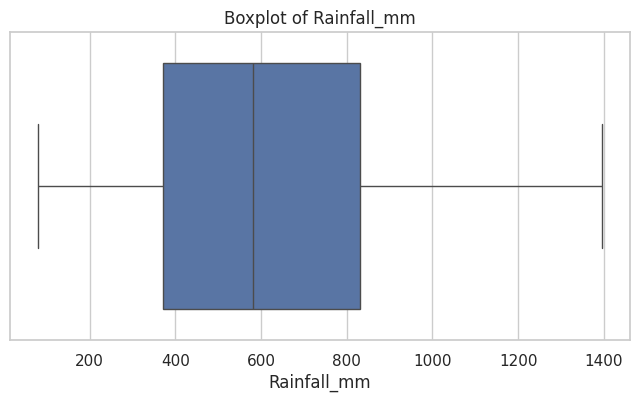

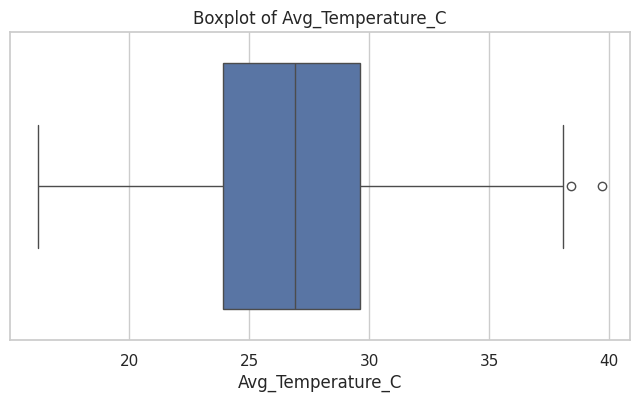

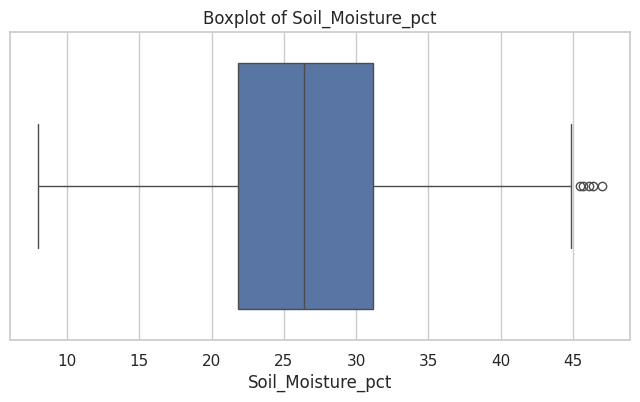

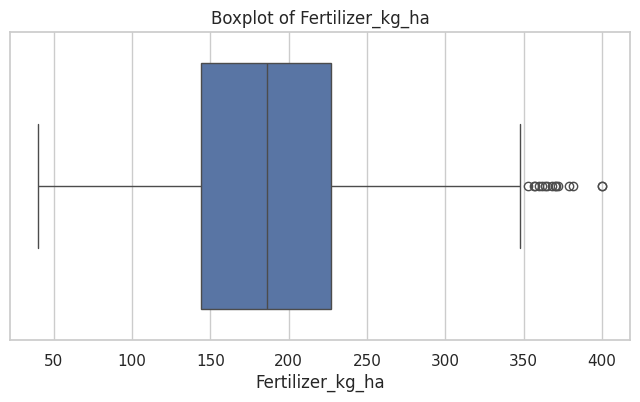

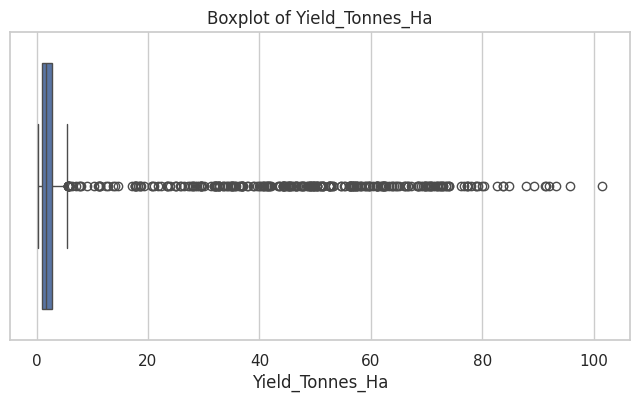

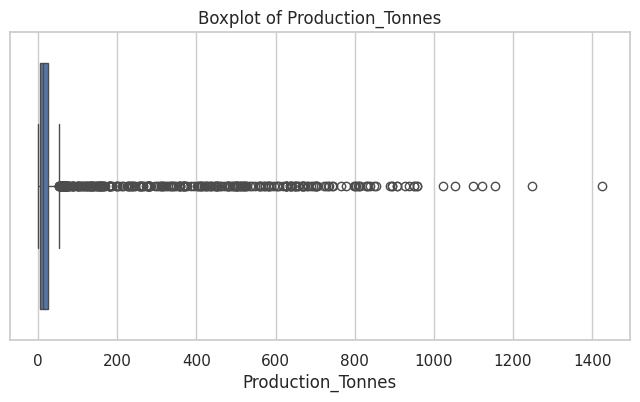

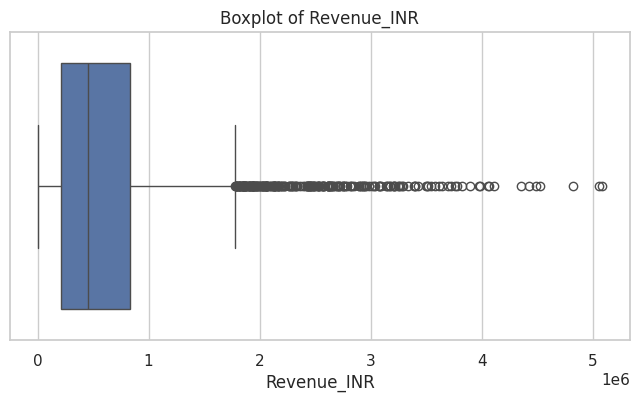

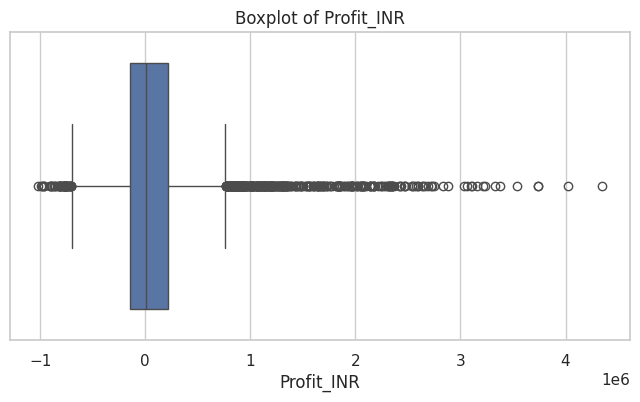

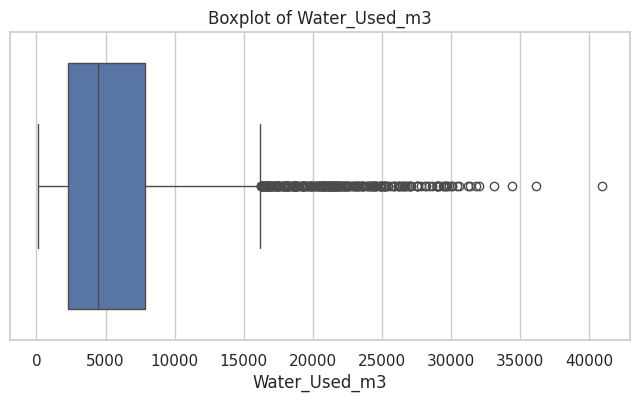

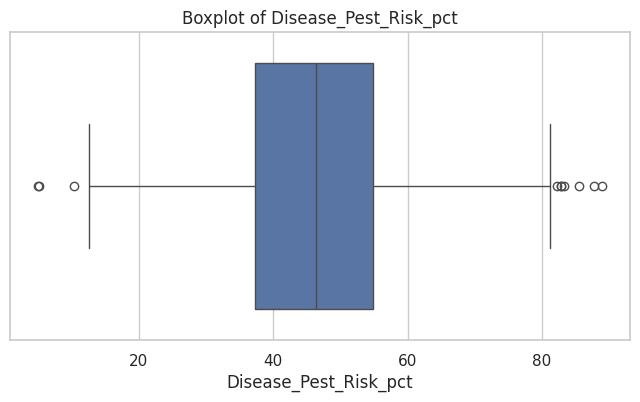

In [13]:
important_numeric_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

for col in important_numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [14]:
outlier_results = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_results.append({
        "Column": col,
        "Outlier_Count": len(outliers),
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

outlier_df = pd.DataFrame(outlier_results)

outlier_df.sort_values("Outlier_Count", ascending=False)

,Column,Outlier_Count,Lower_Bound,Upper_Bound
18,Profit_INR,404,-696111.000000,7.635670e+05
14,Production_Tonnes,333,-23.982500,5.335750e+01
20,Water_Efficiency_t_per_1000m3,322,-3.572875,1.038412e+01
13,Yield_Tonnes_Ha,302,-1.620000,5.500000e+00
19,Water_Used_m3,276,-6072.750000,1.617125e+04
17,Revenue_INR,240,-736519.000000,1.780911e+06
9,Potassium_kg_ha,32,30.100000,1.797000e+02
4,Sunlight_Hours_Day,26,4.350000,1.035000e+01
8,Phosphorus_kg_ha,16,11.400000,1.042000e+02
10,Fertilizer_kg_ha,15,19.137500,3.520375e+02


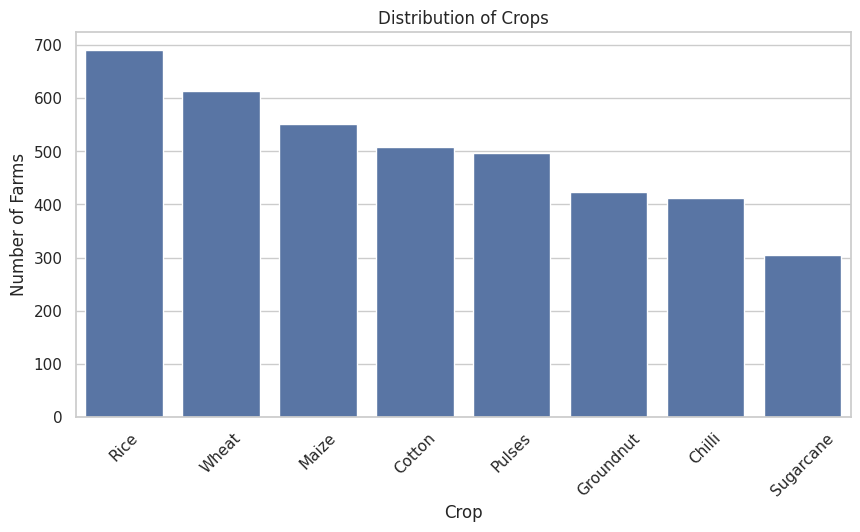

In [15]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)

plt.show()

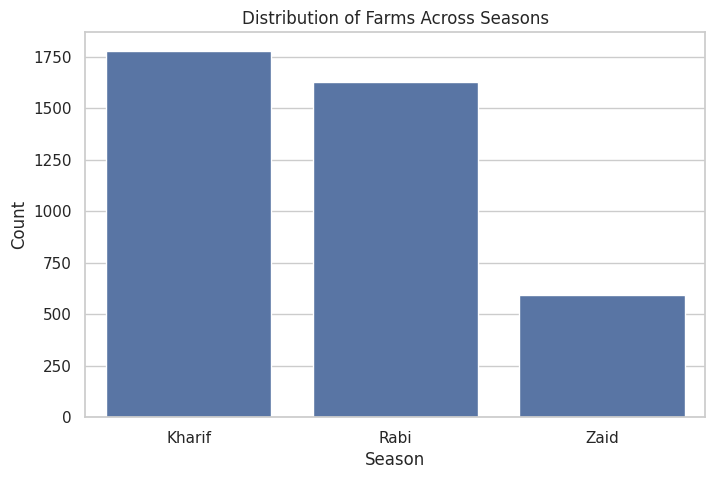

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season",
    order=df["Season"].value_counts().index
)

plt.title("Distribution of Farms Across Seasons")
plt.xlabel("Season")
plt.ylabel("Count")

plt.show()

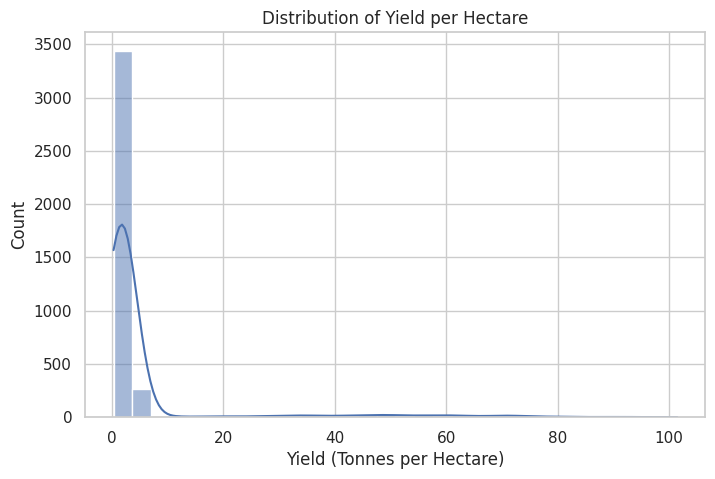

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Yield_Tonnes_Ha"],
    kde=True,
    bins=30
)

plt.title("Distribution of Yield per Hectare")
plt.xlabel("Yield (Tonnes per Hectare)")

plt.show()

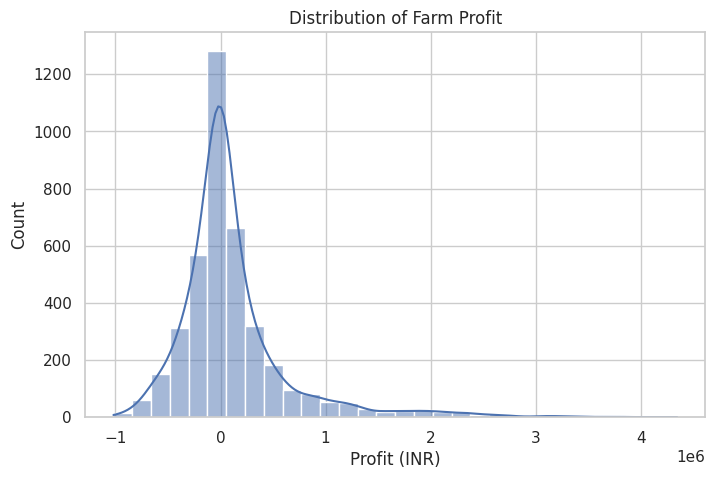

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Profit_INR"],
    kde=True,
    bins=30
)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")

plt.show()

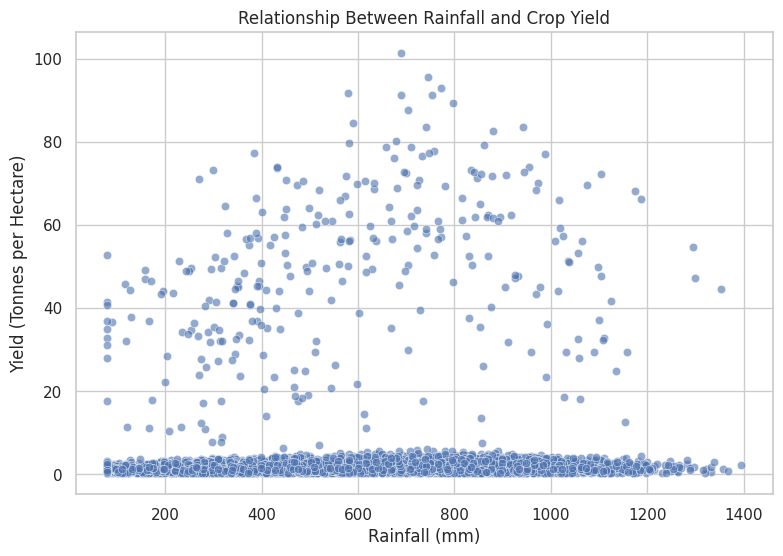

In [19]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.show()

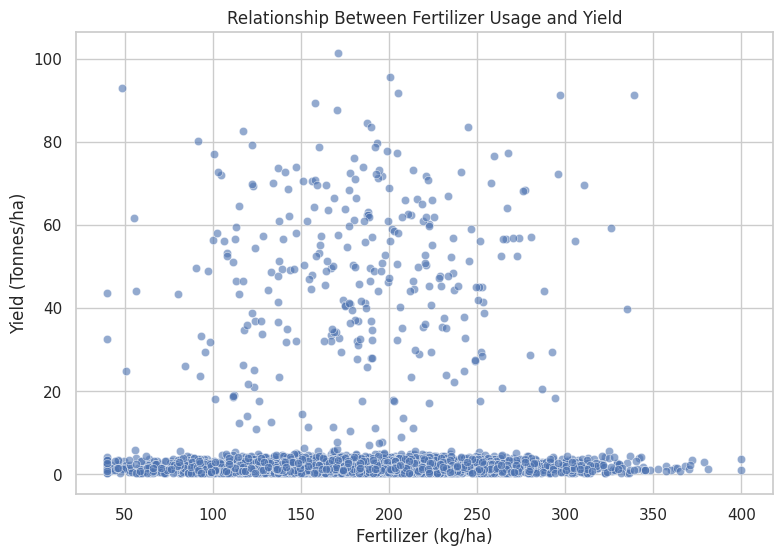

In [20]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)

plt.title("Relationship Between Fertilizer Usage and Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/ha)")

plt.show()

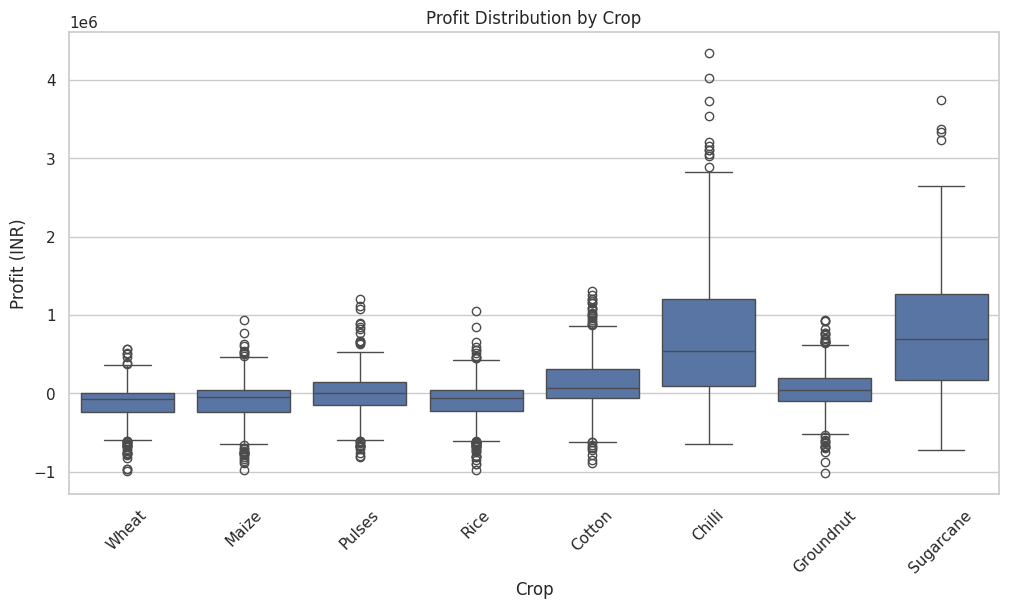

In [21]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Crop",
    y="Profit_INR"
)

plt.title("Profit Distribution by Crop")
plt.xlabel("Crop")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=45)

plt.show()

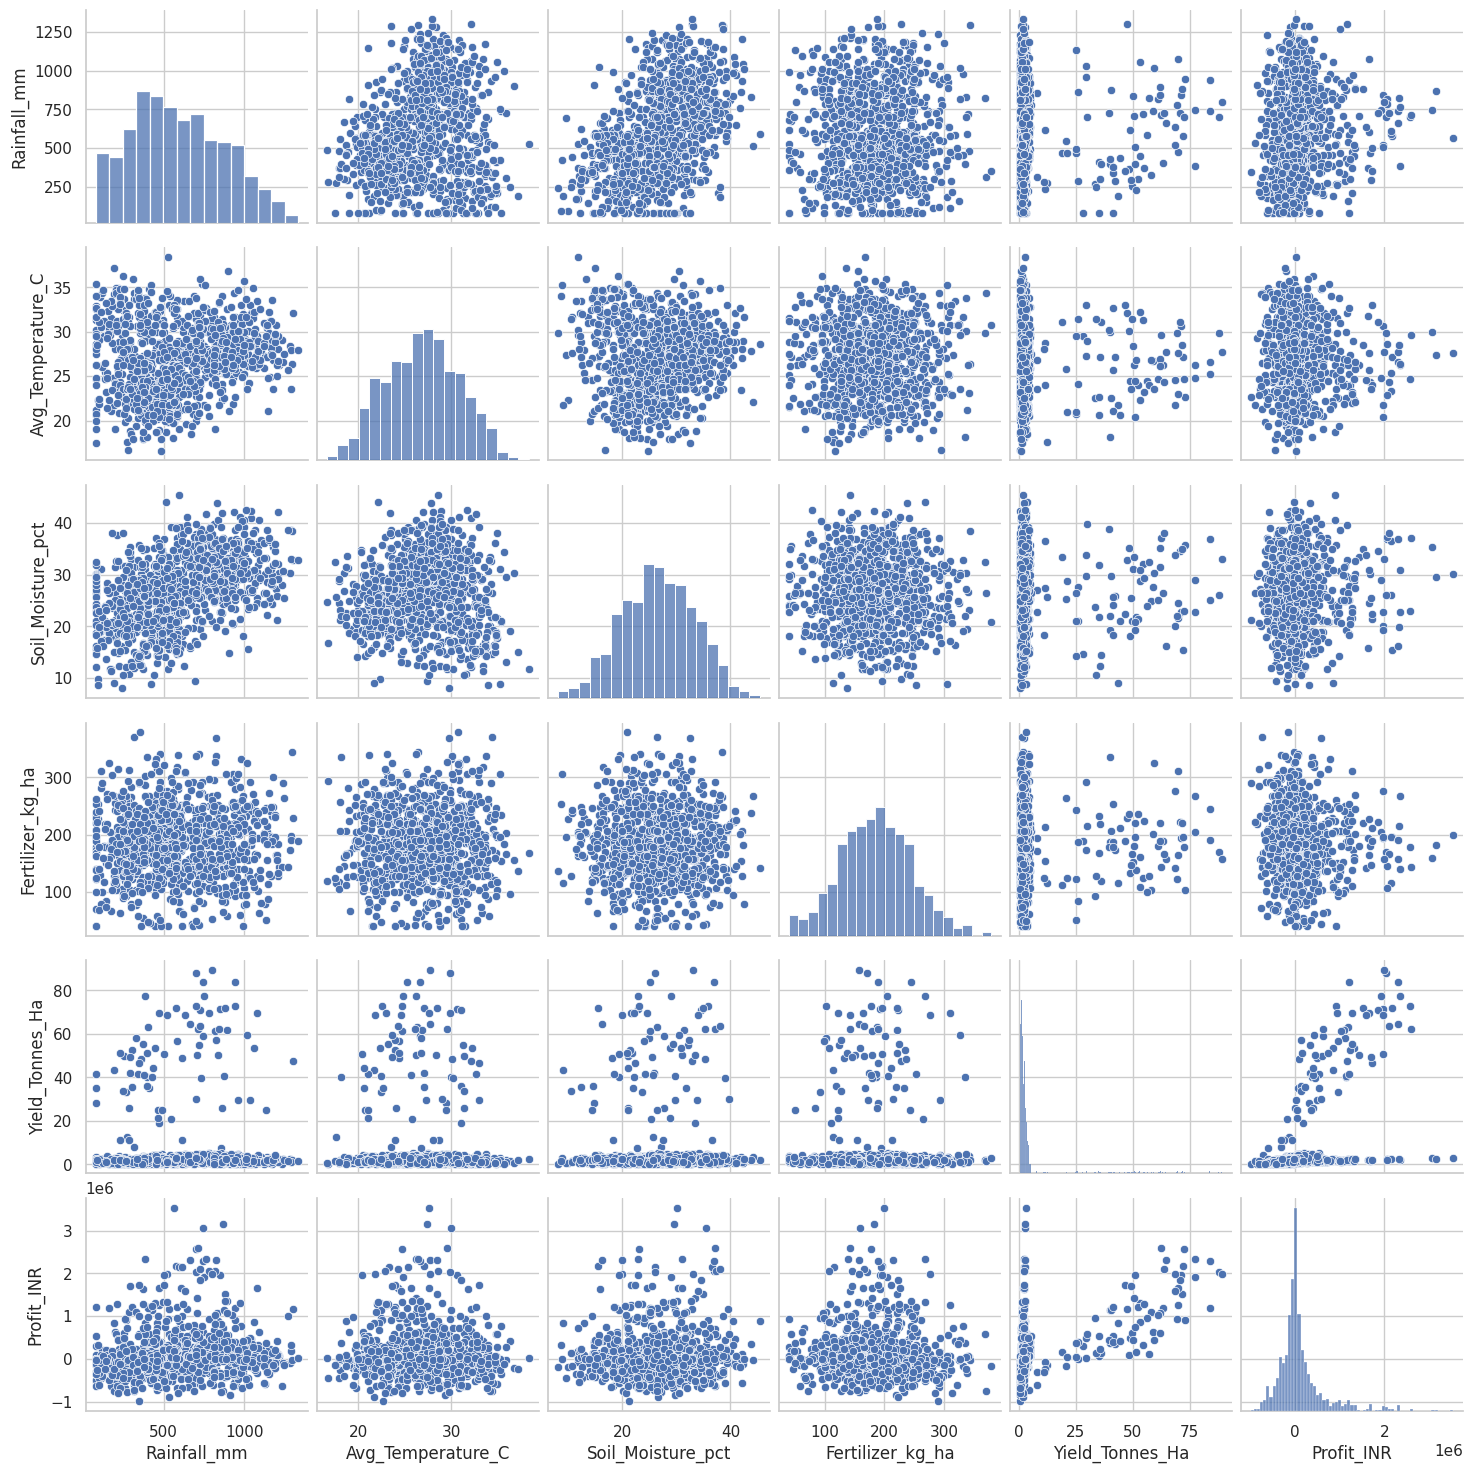

In [22]:
selected_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

sns.pairplot(
    df[selected_cols].sample(1000, random_state=42)
)

plt.show()

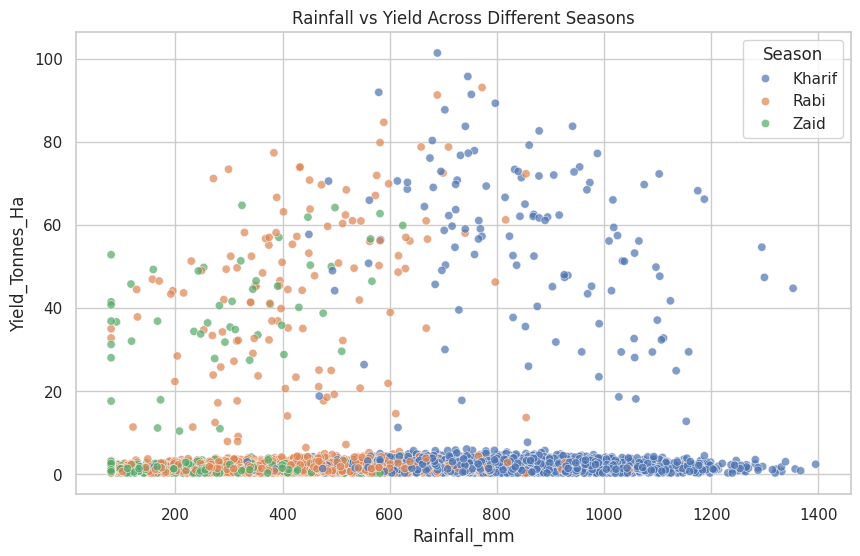

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Rainfall vs Yield Across Different Seasons")

plt.show()

In [24]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

correlation_matrix

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,0.014975,-0.005207,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,0.024602,0.004058,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,0.015861,0.006657,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,0.024623,-0.004028,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,-0.013073,-0.017238,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,-0.010591,-0.010135,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,0.008782,-0.023159,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,-0.032440,0.014280,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,0.012905,-0.029942,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,0.017254,-0.004675,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


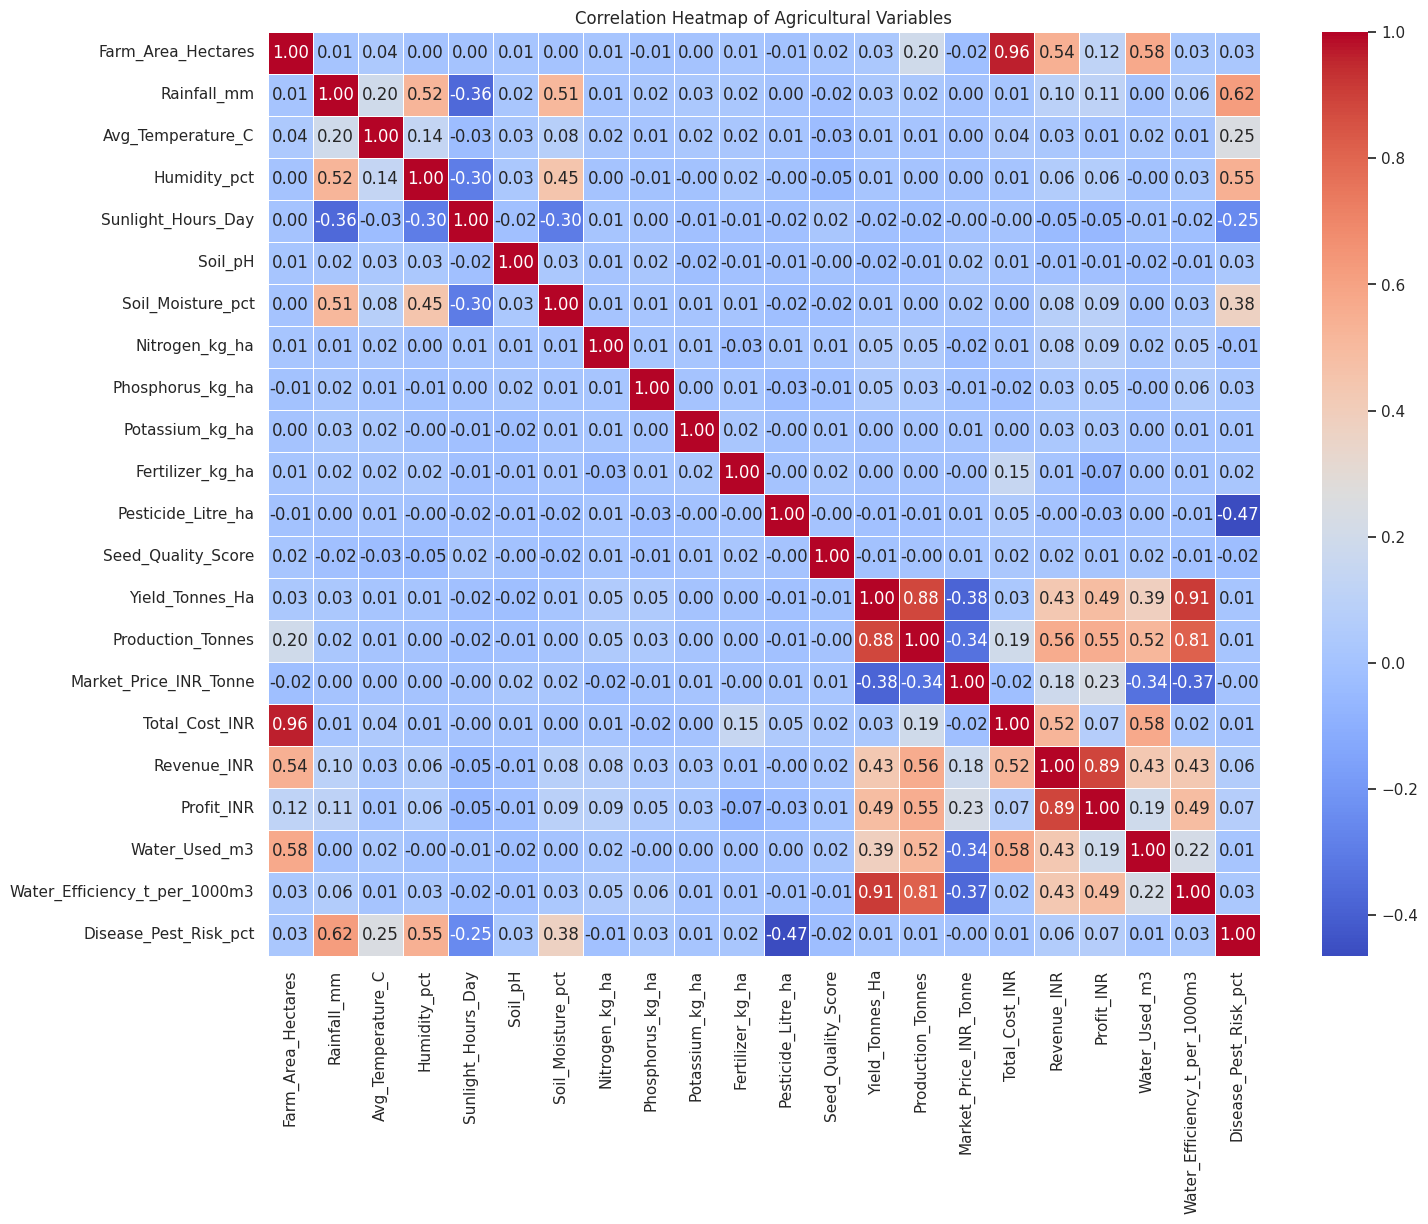

In [25]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Agricultural Variables")

plt.show()

In [26]:
corr_matrix = df.select_dtypes(include=np.number).corr()

corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_correlations = (
    corr_pairs.stack()
    .sort_values(key=abs, ascending=False)
)

print("Top Correlations:")
print(top_correlations.head(15))

Top Correlations:
Farm_Area_Hectares  Total_Cost_INR                   0.962211
Yield_Tonnes_Ha     Water_Efficiency_t_per_1000m3    0.912568
Revenue_INR         Profit_INR                       0.887331
Yield_Tonnes_Ha     Production_Tonnes                0.882813
Production_Tonnes   Water_Efficiency_t_per_1000m3    0.812143
Rainfall_mm         Disease_Pest_Risk_pct            0.621762
Farm_Area_Hectares  Water_Used_m3                    0.576015
Total_Cost_INR      Water_Used_m3                    0.575978
Production_Tonnes   Revenue_INR                      0.563505
                    Profit_INR                       0.554172
Humidity_pct        Disease_Pest_Risk_pct            0.545093
Farm_Area_Hectares  Revenue_INR                      0.543364
Rainfall_mm         Humidity_pct                     0.521069
Total_Cost_INR      Revenue_INR                      0.520709
Production_Tonnes   Water_Used_m3                    0.515557
dtype: float64


In [27]:
crop_profit = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print(crop_profit)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


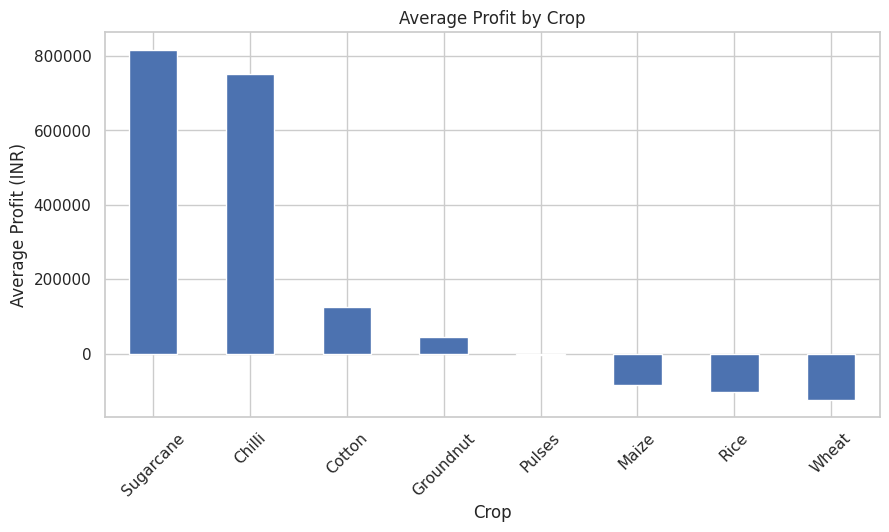

In [28]:
plt.figure(figsize=(10, 5))

crop_profit.plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

In [29]:
irrigation_analysis = df.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Profit_INR": "mean"
})

irrigation_analysis.sort_values(
    "Water_Efficiency_t_per_1000m3",
    ascending=False
)

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Rainfed,4.602142,3549.554275,7.563784,79050.365034
Drip,6.577989,5918.747541,6.267129,219625.997814
Sprinkler,5.160627,6208.258856,4.669805,91121.079019
Flood,4.863977,8026.472519,3.438853,73354.022901


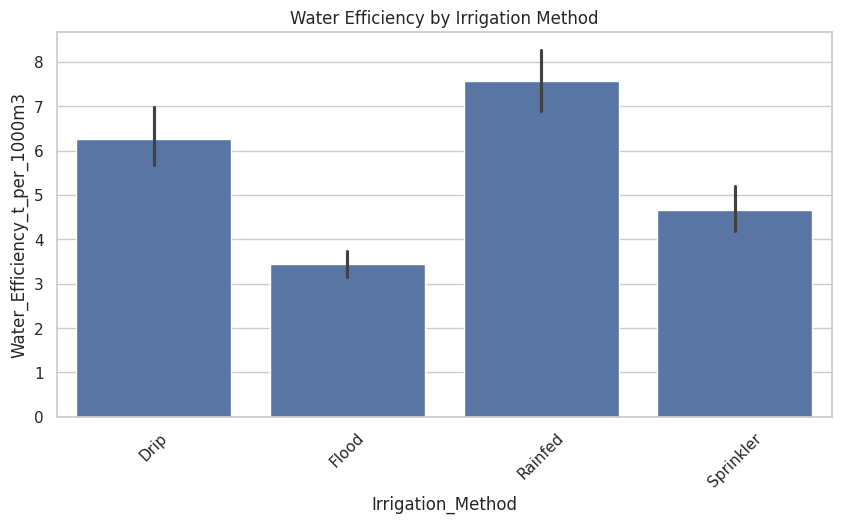

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean"
)

plt.title("Water Efficiency by Irrigation Method")
plt.xticks(rotation=45)

plt.show()

In [31]:
state_analysis = df.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean"
})

state_analysis = state_analysis.sort_values(
    "Profit_INR",
    ascending=False
)

state_analysis

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
State,,,
Punjab,6.121116,52.233099,136025.636364
Maharashtra,5.017480,43.984043,135428.855469
Karnataka,5.685481,47.732720,119422.335378
Tamil Nadu,4.875175,40.840371,117744.748454
Gujarat,5.659016,48.331988,117568.235656
Telangana,5.044477,39.254186,108829.616279
Madhya Pradesh,4.989940,37.559517,86840.756539
Andhra Pradesh,4.628771,36.913157,73453.527410


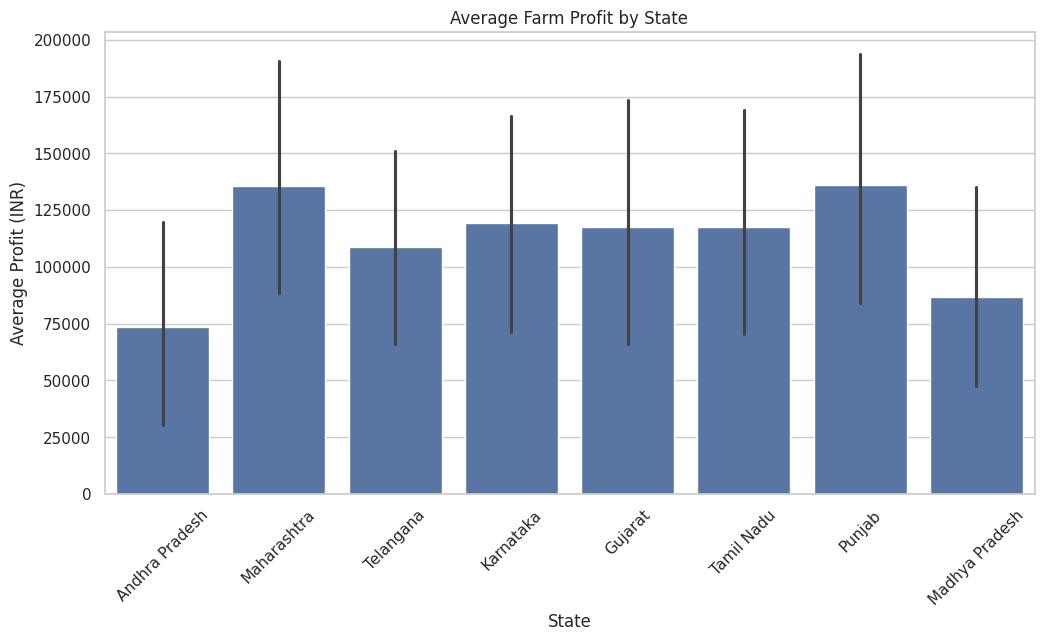

In [32]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="State",
    y="Profit_INR",
    estimator="mean"
)

plt.title("Average Farm Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

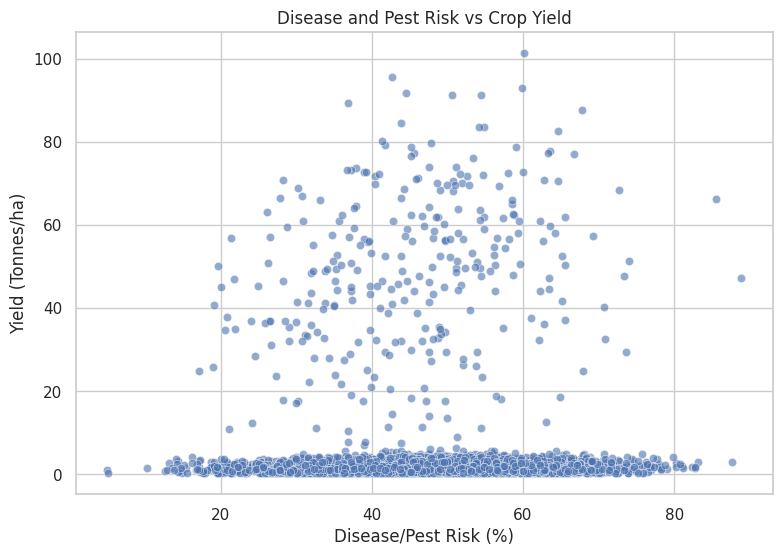

In [33]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Disease_Pest_Risk_pct",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)

plt.title("Disease and Pest Risk vs Crop Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/ha)")

plt.show()

In [34]:
risk_yield_corr = df[
    ["Disease_Pest_Risk_pct", "Yield_Tonnes_Ha"]
].corr()

risk_yield_corr

,Disease_Pest_Risk_pct,Yield_Tonnes_Ha
Disease_Pest_Risk_pct,1.000000,0.014292
Yield_Tonnes_Ha,0.014292,1.000000


In [35]:
top_farms = df.nlargest(
    10,
    "Profit_INR"
)[[
    "Farm_ID",
    "State",
    "District",
    "Crop",
    "Season",
    "Yield_Tonnes_Ha",
    "Revenue_INR",
    "Profit_INR"
]]

top_farms

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,3.90,5057448,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,2.92,5080900,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,4485260,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3.01,4522464,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3.09,4825365,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,4350998,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,4428460,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,4108301,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3.02,4055609,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,2.53,3987664,3159447
